# World Cup Analysis (1930-2026)

Analysis of FIFA World Cup data spanning from the first tournament in 1930 through the upcoming 2026 edition.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')

wc_1930_2014 = pd.read_csv("WC_1930-2014.csv")
wc_2018 = pd.read_csv("WC_2018.csv")
wc_2022 = pd.read_csv("WC_2022.csv")
wc_2026_matches = pd.read_csv("WC_2026/matches.csv")
wc_2026_teams = pd.read_csv("WC_2026/teams.csv")
wc_2026_host_cities = pd.read_csv("WC_2026/host_cities.csv")
wc_2026_stages = pd.read_csv("WC_2026/tournament_stages.csv")

## 1. Data Exploration

In [27]:
print("=== WC 1930-2014 ===")
print(f"Shape: {wc_1930_2014.shape}")
wc_1930_2014.info()

=== WC 1930-2014 ===
Shape: (4572, 20)
<class 'pandas.DataFrame'>
RangeIndex: 4572 entries, 0 to 4571
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  852 non-null    float64
 1   Datetime              852 non-null    str    
 2   Stage                 852 non-null    str    
 3   Stadium               852 non-null    str    
 4   City                  852 non-null    str    
 5   Home Team Name        852 non-null    str    
 6   Home Team Goals       852 non-null    float64
 7   Away Team Goals       852 non-null    float64
 8   Away Team Name        852 non-null    str    
 9   Win conditions        852 non-null    str    
 10  Attendance            850 non-null    float64
 11  Half-time Home Goals  852 non-null    float64
 12  Half-time Away Goals  852 non-null    float64
 13  Referee               852 non-null    str    
 14  Assistant 1           852 non-null    str   

In [ ]:
print("=== WC 2018 ===")
print(f"Shape: {wc_2018.shape}")
wc_2018.info()

In [ ]:
wc_2018.head()

In [28]:
print("=== WC 2022 ===")
print(f"Shape: {wc_2022.shape}")
wc_2022.info()

=== WC 2022 ===
Shape: (64, 88)
<class 'pandas.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 88 columns):
 #   Column                                                 Non-Null Count  Dtype
---  ------                                                 --------------  -----
 0   team1                                                  64 non-null     str  
 1   team2                                                  64 non-null     str  
 2   possession team1                                       64 non-null     str  
 3   possession team2                                       64 non-null     str  
 4   possession in contest                                  64 non-null     str  
 5   number of goals team1                                  64 non-null     int64
 6   number of goals team2                                  64 non-null     int64
 7   date                                                   64 non-null     str  
 8   hour                                               

In [29]:
print("=== WC 2026 Matches ===")
print(f"Shape: {wc_2026_matches.shape}")
wc_2026_matches.info()
print("\n=== WC 2026 Teams ===")
print(f"Shape: {wc_2026_teams.shape}")
wc_2026_teams.info()

=== WC 2026 Matches ===
Shape: (104, 8)
<class 'pandas.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            104 non-null    int64  
 1   match_number  104 non-null    int64  
 2   home_team_id  72 non-null     float64
 3   away_team_id  72 non-null     float64
 4   city_id       104 non-null    int64  
 5   stage_id      104 non-null    int64  
 6   kickoff_at    104 non-null    str    
 7   match_label   104 non-null    str    
dtypes: float64(2), int64(4), str(2)
memory usage: 6.6 KB

=== WC 2026 Teams ===
Shape: (48, 5)
<class 'pandas.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   id              48 non-null     int64
 1   team_name       48 non-null     str  
 2   fifa_code       48 non-null     str  
 3   group_letter    48 non-null   

In [30]:
print("=== WC 2026 Host Cities ===")
wc_2026_host_cities.head()

=== WC 2026 Host Cities ===


,id,city_name,country,venue_name,region_cluster,airport_code
0,1,Atlanta,USA,Mercedes-Benz Stadium,East,ATL
1,2,Boston,USA,Gillette Stadium,East,BOS
2,3,Dallas,USA,AT&T Stadium,Central,DAL
3,4,Houston,USA,NRG Stadium,Central,IAH
4,5,Kansas City,USA,Arrowhead Stadium,Central,MCI


In [31]:
print("=== WC 2026 Tournament Stages ===")
wc_2026_stages.head()

=== WC 2026 Tournament Stages ===


,id,stage_name,stage_order
0,1,Group Stage,1
1,2,Round of 32,2
2,3,Round of 16,3
3,4,Quarterfinals,4
4,5,Semifinals,5


In [32]:
print("Missing values - WC 1930-2014:")
print(wc_1930_2014.isnull().sum()[wc_1930_2014.isnull().sum() > 0])
print("\nMissing values - WC 2022:")
print(wc_2022.isnull().sum()[wc_2022.isnull().sum() > 0])
print("\nMissing values - WC 2026 Matches:")
print(wc_2026_matches.isnull().sum()[wc_2026_matches.isnull().sum() > 0])

Missing values - WC 1930-2014:
Year                    3720
Datetime                3720
Stage                   3720
Stadium                 3720
City                    3720
Home Team Name          3720
Home Team Goals         3720
Away Team Goals         3720
Away Team Name          3720
Win conditions          3720
Attendance              3722
Half-time Home Goals    3720
Half-time Away Goals    3720
Referee                 3720
Assistant 1             3720
Assistant 2             3720
RoundID                 3720
MatchID                 3720
Home Team Initials      3720
Away Team Initials      3720
dtype: int64

Missing values - WC 2022:
Series([], dtype: int64)

Missing values - WC 2026 Matches:
home_team_id    32
away_team_id    32
dtype: int64


## 2. Data Cleaning & Harmonization

In [33]:
# Drop trailing empty rows
wc_1930_2014 = wc_1930_2014.dropna(subset=['Year'])
wc_1930_2014['Year'] = wc_1930_2014['Year'].astype(int)

# Parse datetime
wc_1930_2014['Datetime'] = pd.to_datetime(wc_1930_2014['Datetime'].str.strip(), format='mixed', dayfirst=True)

# Normalize team names across all datasets
team_name_map = {
    'Germany': 'Germany',
    'Korea Republic': 'South Korea',
    'Korea': 'South Korea',
    'IR Iran': 'Iran',
    'IRAN': 'Iran',
    'Cote d\'Ivoire': "Côte d'Ivoire",
    'Porugal': 'Portugal',
    'Costarica': 'Costa Rica',
    'Columbia': 'Colombia',
}
wc_1930_2014['Home Team Name'] = wc_1930_2014['Home Team Name'].replace(team_name_map)
wc_1930_2014['Away Team Name'] = wc_1930_2014['Away Team Name'].replace(team_name_map)

wc_2022['team1'] = wc_2022['team1'].replace(team_name_map)
wc_2022['team2'] = wc_2022['team2'].replace(team_name_map)

wc_2026_teams['team_name'] = wc_2026_teams['team_name'].replace(team_name_map)

print(f"Historical matches after cleaning: {len(wc_1930_2014)}")
print(f"Year range: {wc_1930_2014['Year'].min()} - {wc_1930_2014['Year'].max()}")

Historical matches after cleaning: 852
Year range: 1930 - 2014


In [34]:
# Clean 2022 data
wc_2022['number of goals team1'] = pd.to_numeric(wc_2022['number of goals team1'])
wc_2022['number of goals team2'] = pd.to_numeric(wc_2022['number of goals team2'])

# Parse possession percentages
for col in ['possession team1', 'possession team2', 'possession in contest']:
    wc_2022[col] = wc_2022[col].str.rstrip('%').astype(float) / 100

# Add derived columns
wc_2022['total_goals'] = wc_2022['number of goals team1'] + wc_2022['number of goals team2']
wc_2022['goal_diff'] = wc_2022['number of goals team1'] - wc_2022['number of goals team2']

print(f"2022 matches: {len(wc_2022)}")
wc_2022[['team1', 'team2', 'possession team1', 'possession team2', 'number of goals team1', 'number of goals team2', 'category']].head()

2022 matches: 64


,team1,team2,possession team1,possession team2,number of goals team1,number of goals team2,category
0,QATAR,ECUADOR,0.42,0.50,0,2,Group A
1,ENGLAND,IRAN,0.72,0.19,6,2,Group B
2,SENEGAL,NETHERLANDS,0.44,0.45,0,2,Group A
3,UNITED STATES,WALES,0.51,0.39,1,1,Group B
4,ARGENTINA,SAUDI ARABIA,0.64,0.24,1,2,Group C


In [35]:
# Join 2026 matches with stage names
wc_2026_matches = wc_2026_matches.merge(
    wc_2026_stages, left_on='stage_id', right_on='id', suffixes=('', '_stage')
)

# Flag placeholder teams
placeholders = wc_2026_teams[wc_2026_teams['is_placeholder'] == True]
print(f"Placeholder teams in 2026: {len(placeholders)}")
print(placeholders[['team_name', 'fifa_code', 'group_letter']].to_string(index=False))

# Matches by stage
print("\nMatches per stage:")
print(wc_2026_matches['stage_name'].value_counts().sort_index())

Placeholder teams in 2026: 6
            team_name fifa_code group_letter
Winner UEFA Playoff D      UEPD            A
Winner UEFA Playoff A      UEPA            B
Winner UEFA Playoff C      UEPC            D
Winner UEFA Playoff B      UEPB            F
Winner FIFA Playoff 2      FP02            I
Winner FIFA Playoff 1      FP01            K

Matches per stage:
stage_name
Final                   1
Group Stage            72
Quarterfinals           4
Round of 16             8
Round of 32            16
Semifinals              2
Third Place Playoff     1
Name: count, dtype: int64


In [ ]:
# Clean 2018 data - handle multi-line headers and N/A values
# First, strip newlines from column names
wc_2018.columns = [c.replace('\n', ' ').strip() for c in wc_2018.columns]

# Drop unnamed trailing columns
wc_2018 = wc_2018[[c for c in wc_2018.columns if not c.startswith('Unnamed')]]

# Rename for clarity
wc_2018.columns = [
    'Team', 'Group', 'Prev Appearances', 'Prev Titles', 'Prev Finals',
    'Prev Semifinals', 'FIFA Rank',
    'Opp1', 'Match1_Idx', 'H2H1_WL', 'H2H1_Goals',
    'Opp2', 'Match2_Idx', 'H2H2_WL', 'H2H2_Goals',
    'Opp3', 'Match3_Idx', 'H2H3_WL', 'H2H3_Goals'
]

# Drop trailing empty rows
wc_2018 = wc_2018.dropna(subset=['Team'])

# Convert numeric columns
num_cols = ['Prev Appearances', 'Prev Titles', 'Prev Finals', 'Prev Semifinals', 'FIFA Rank']
for col in num_cols:
    wc_2018[col] = pd.to_numeric(wc_2018[col], errors='coerce')

# Normalize team names across all columns
opp_cols = ['Opp1', 'Opp2', 'Opp3']
wc_2018['Team'] = wc_2018['Team'].replace(team_name_map)
for col in opp_cols:
    wc_2018[col] = wc_2018[col].replace(team_name_map)

# Parse H2H columns (numeric W-L difference and goal difference)
for prefix in ['H2H1', 'H2H2', 'H2H3']:
    wc_2018[f'{prefix}_WL'] = pd.to_numeric(wc_2018[f'{prefix}_WL'], errors='coerce')
    wc_2018[f'{prefix}_Goals'] = pd.to_numeric(wc_2018[f'{prefix}_Goals'], errors='coerce')

print(f"2018 teams: {len(wc_2018)}")
print(f"Groups: {sorted(wc_2018['Group'].unique())}")
wc_2018[['Team', 'Group', 'FIFA Rank', 'Prev Titles', 'Prev Appearances']].head(10)

## 3. Historical Analysis (1930-2014)

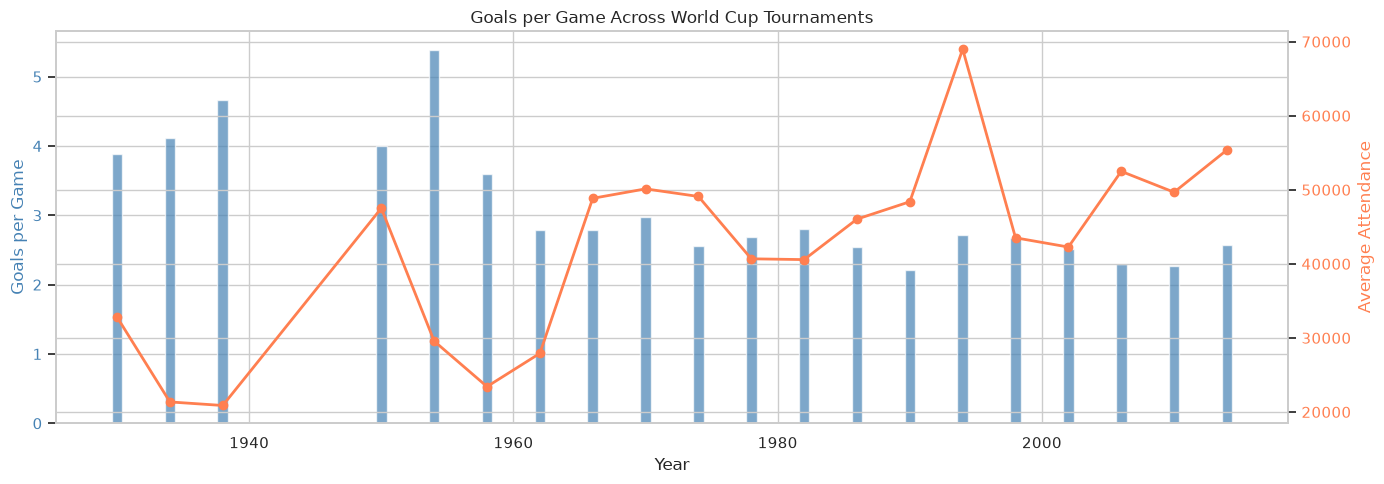

In [36]:
# Goals per game by tournament year
yearly = wc_1930_2014.groupby('Year').agg(
    matches=('MatchID', 'count'),
    total_goals=('Home Team Goals', 'sum'),
    avg_attendance=('Attendance', 'mean')
).reset_index()
yearly['total_goals'] = yearly['total_goals'] + wc_1930_2014.groupby('Year')['Away Team Goals'].sum().values
yearly['goals_per_game'] = yearly['total_goals'] / yearly['matches']

fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.bar(yearly['Year'], yearly['goals_per_game'], color='steelblue', alpha=0.7, label='Goals per Game')
ax1.set_xlabel('Year')
ax1.set_ylabel('Goals per Game', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.set_title('Goals per Game Across World Cup Tournaments')

ax2 = ax1.twinx()
ax2.plot(yearly['Year'], yearly['avg_attendance'], color='coral', marker='o', linewidth=2, label='Avg Attendance')
ax2.set_ylabel('Average Attendance', color='coral')
ax2.tick_params(axis='y', labelcolor='coral')

fig.tight_layout()
plt.show()

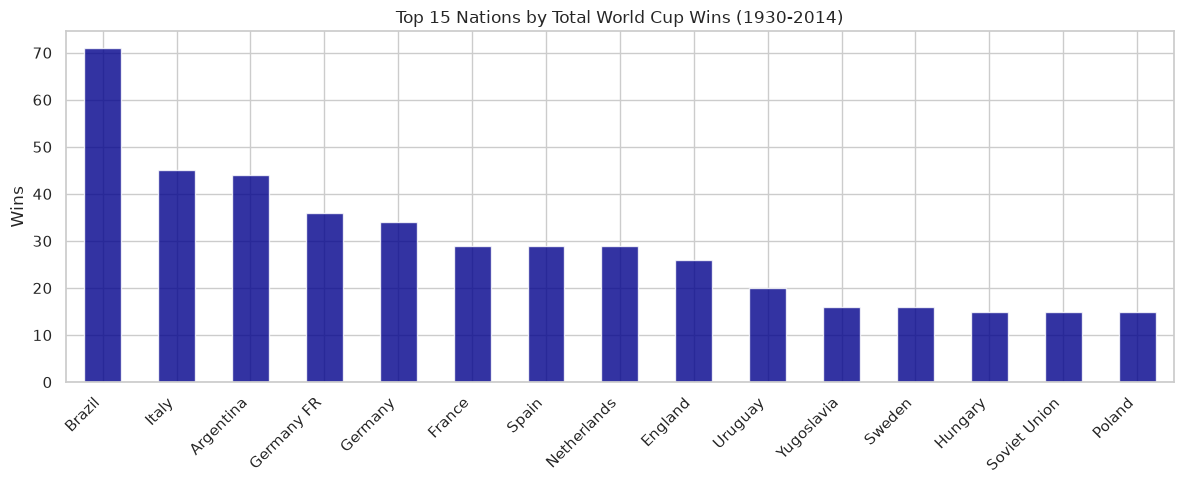

In [37]:
# Top nations by total wins
home_wins = wc_1930_2014[wc_1930_2014['Home Team Goals'] > wc_1930_2014['Away Team Goals']].groupby('Home Team Name').size()
away_wins = wc_1930_2014[wc_1930_2014['Away Team Goals'] > wc_1930_2014['Home Team Goals']].groupby('Away Team Name').size()
total_wins = (home_wins.add(away_wins, fill_value=0)).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 5))
total_wins.plot(kind='bar', color='darkblue', alpha=0.8, ax=ax)
ax.set_title('Top 15 Nations by Total World Cup Wins (1930-2014)')
ax.set_ylabel('Wins')
ax.set_xlabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

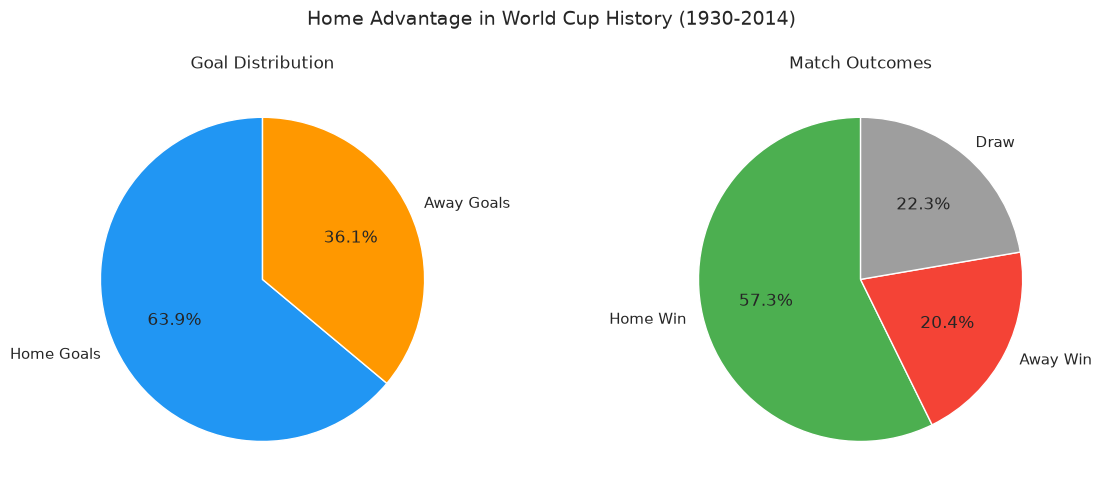

In [38]:
# Home advantage analysis
home_goals = wc_1930_2014['Home Team Goals'].sum()
away_goals = wc_1930_2014['Away Team Goals'].sum()
total = home_goals + away_goals

home_wins_count = len(wc_1930_2014[wc_1930_2014['Home Team Goals'] > wc_1930_2014['Away Team Goals']])
away_wins_count = len(wc_1930_2014[wc_1930_2014['Away Team Goals'] > wc_1930_2014['Home Team Goals']])
draws = len(wc_1930_2014[wc_1930_2014['Home Team Goals'] == wc_1930_2014['Away Team Goals']])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].pie([home_goals, away_goals], labels=['Home Goals', 'Away Goals'],
            autopct='%1.1f%%', colors=['#2196F3', '#FF9800'], startangle=90)
axes[0].set_title('Goal Distribution')

axes[1].pie([home_wins_count, away_wins_count, draws],
            labels=['Home Win', 'Away Win', 'Draw'],
            autopct='%1.1f%%', colors=['#4CAF50', '#F44336', '#9E9E9E'], startangle=90)
axes[1].set_title('Match Outcomes')

fig.suptitle('Home Advantage in World Cup History (1930-2014)', fontsize=14)
plt.tight_layout()
plt.show()

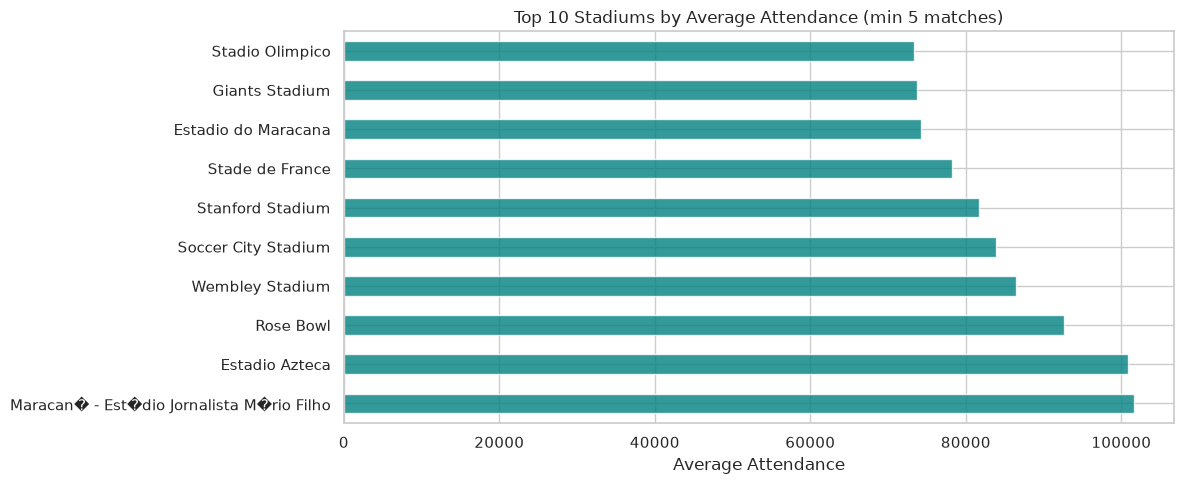

In [39]:
# Top stadiums by average attendance
stadium_att = wc_1930_2014.groupby('Stadium').agg(
    avg_att=('Attendance', 'mean'),
    matches=('MatchID', 'count')
).query('matches >= 5').sort_values('avg_att', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(12, 5))
stadium_att['avg_att'].plot(kind='barh', color='teal', alpha=0.8, ax=ax)
ax.set_title('Top 10 Stadiums by Average Attendance (min 5 matches)')
ax.set_xlabel('Average Attendance')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

In [40]:
# Historical finals
finals = wc_1930_2014[wc_1930_2014['Stage'] == 'Final'][['Year', 'Home Team Name', 'Home Team Goals', 'Away Team Goals', 'Away Team Name']].copy()
finals['Score'] = finals['Home Team Goals'].astype(str) + ' - ' + finals['Away Team Goals'].astype(str)
finals['Winner'] = finals.apply(lambda r: r['Home Team Name'] if r['Home Team Goals'] > r['Away Team Goals'] else r['Away Team Name'], axis=1)

print("World Cup Finals (1930-2014):")
finals[['Year', 'Home Team Name', 'Score', 'Away Team Name', 'Winner']]

World Cup Finals (1930-2014):


,Year,Home Team Name,Score,Away Team Name,Winner
17,1930,Uruguay,4.0 - 2.0,Argentina,Uruguay
34,1934,Italy,2.0 - 1.0,Czechoslovakia,Italy
52,1938,Italy,4.0 - 2.0,Hungary,Italy
100,1954,Germany FR,3.0 - 2.0,Hungary,Germany FR
135,1958,Brazil,5.0 - 2.0,Sweden,Brazil
167,1962,Brazil,3.0 - 1.0,Czechoslovakia,Brazil
199,1966,England,4.0 - 2.0,Germany FR,England
231,1970,Brazil,4.0 - 1.0,Italy,Brazil
269,1974,Netherlands,1.0 - 2.0,Germany FR,Germany FR
307,1978,Argentina,3.0 - 1.0,Netherlands,Argentina


## 3.5. 2018 Team Preview Analysis

In [ ]:
# FIFA Rank distribution by group
fig, ax = plt.subplots(figsize=(12, 6))
groups_sorted = sorted(wc_2018['Group'].unique())
data_by_group = [wc_2018[wc_2018['Group'] == g]['FIFA Rank'].values for g in groups_sorted]
bp = ax.boxplot(data_by_group, patch_artist=True, tick_labels=groups_sorted)
colors_bp = plt.cm.Set3(np.linspace(0, 1, len(groups_sorted)))
for patch, color in zip(bp['boxes'], colors_bp):
    patch.set_facecolor(color)
ax.set_title('2018 FIFA Rank Distribution by Group')
ax.set_xlabel('Group')
ax.set_ylabel('FIFA Rank (lower = better)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
# Team experience: Previous appearances vs titles
fig, ax = plt.subplots(figsize=(12, 6))
scatter = ax.scatter(wc_2018['Prev Appearances'], wc_2018['Prev Titles'],
                     c=wc_2018['FIFA Rank'], cmap='RdYlGn', s=100, alpha=0.8, edgecolors='gray')
plt.colorbar(scatter, label='FIFA Rank (lower = better)')
for _, row in wc_2018.iterrows():
    if row['Prev Titles'] > 0 or row['Prev Appearances'] > 12:
        ax.annotate(row['Team'], (row['Prev Appearances'], row['Prev Titles']),
                   fontsize=7, ha='center', va='bottom')
ax.set_title('2018 Teams: Experience vs Success')
ax.set_xlabel('Previous World Cup Appearances')
ax.set_ylabel('Previous Titles Won')
plt.tight_layout()
plt.show()

In [ ]:
# Head-to-head record analysis (H2H columns are numeric W-L differences)
wc_2018['Total_H2H_WL'] = wc_2018['H2H1_WL'].fillna(0) + wc_2018['H2H2_WL'].fillna(0) + wc_2018['H2H3_WL'].fillna(0)
wc_2018['Total_H2H_Goals'] = wc_2018['H2H1_Goals'].fillna(0) + wc_2018['H2H2_Goals'].fillna(0) + wc_2018['H2H3_Goals'].fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# H2H win-loss balance vs FIFA Rank
valid_h2h = wc_2018.dropna(subset=['Total_H2H_WL', 'FIFA Rank'])
colors = ['green' if x > 0 else 'red' if x < 0 else 'gray' for x in valid_h2h['Total_H2H_WL']]
axes[0].barh(valid_h2h['Team'], valid_h2h['Total_H2H_WL'], color=colors, alpha=0.7)
axes[0].axvline(x=0, color='black', linewidth=0.5)
axes[0].set_title('2018: Net H2H Record vs Group Opponents')
axes[0].set_xlabel('Win-Loss Difference (positive = more wins)')

# H2H goal difference vs FIFA Rank
axes[1].scatter(valid_h2h['FIFA Rank'], valid_h2h['Total_H2H_Goals'],
                c=valid_h2h['Total_H2H_WL'], cmap='RdYlGn', s=80, alpha=0.8, edgecolors='gray')
plt.colorbar(axes[1].collections[0], ax=axes[1], label='W-L Difference')
for _, row in valid_h2h.iterrows():
    if abs(row['Total_H2H_Goals']) > 15 or row['FIFA Rank'] < 5:
        axes[1].annotate(row['Team'], (row['FIFA Rank'], row['Total_H2H_Goals']),
                        fontsize=7, ha='center', va='bottom')
axes[1].set_title('2018: FIFA Rank vs H2H Goal Difference')
axes[1].set_xlabel('FIFA Rank (lower = better)')
axes[1].set_ylabel('Goal Difference vs Group Opponents')

plt.tight_layout()
plt.show()

## 4. 2022 Deep Dive

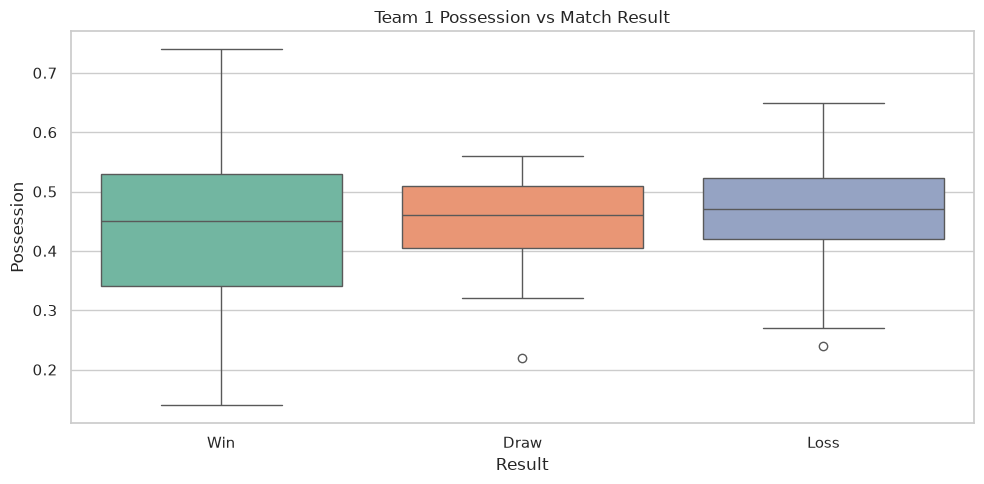

In [41]:
# Possession vs match outcome
wc_2022['result_team1'] = wc_2022['goal_diff'].apply(lambda x: 'Win' if x > 0 else ('Loss' if x < 0 else 'Draw'))

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=wc_2022, x='result_team1', y='possession team1',
            order=['Win', 'Draw', 'Loss'], palette='Set2', ax=ax)
ax.set_title('Team 1 Possession vs Match Result')
ax.set_ylabel('Possession')
ax.set_xlabel('Result')
plt.tight_layout()
plt.show()

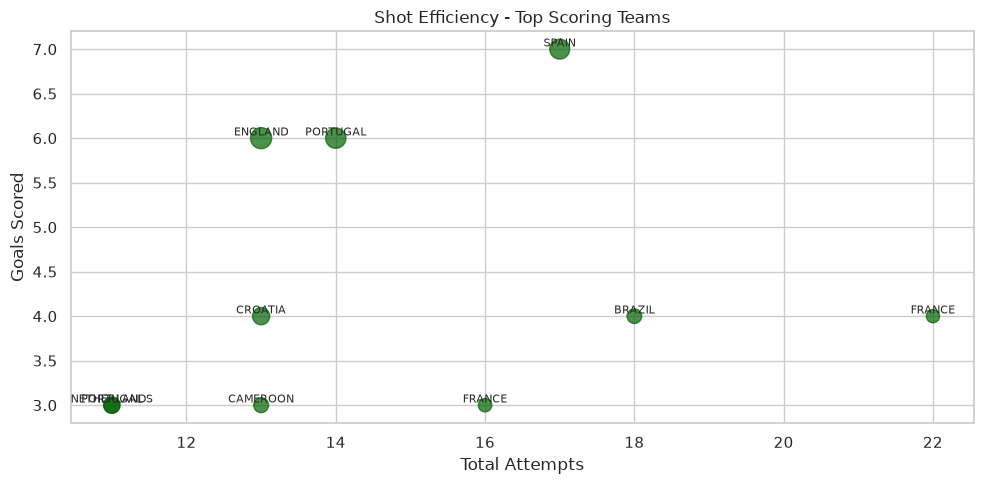

In [42]:
# Shot efficiency (goals / total attempts)
wc_2022['conversion_team1'] = wc_2022['number of goals team1'] / wc_2022['total attempts team1']
wc_2022['conversion_team2'] = wc_2022['number of goals team2'] / wc_2022['total attempts team2']

top_scorers = wc_2022.nlargest(10, 'number of goals team1')[['team1', 'number of goals team1', 'total attempts team1', 'conversion_team1']]
top_scorers.columns = ['Team', 'Goals', 'Attempts', 'Conversion Rate']

fig, ax = plt.subplots(figsize=(10, 5))
scatter = ax.scatter(top_scorers['Attempts'], top_scorers['Goals'],
                     s=top_scorers['Conversion Rate'] * 500, alpha=0.7, color='darkgreen')
for _, row in top_scorers.iterrows():
    ax.annotate(row['Team'], (row['Attempts'], row['Goals']), fontsize=8, ha='center', va='bottom')
ax.set_title('Shot Efficiency - Top Scoring Teams')
ax.set_xlabel('Total Attempts')
ax.set_ylabel('Goals Scored')
plt.tight_layout()
plt.show()

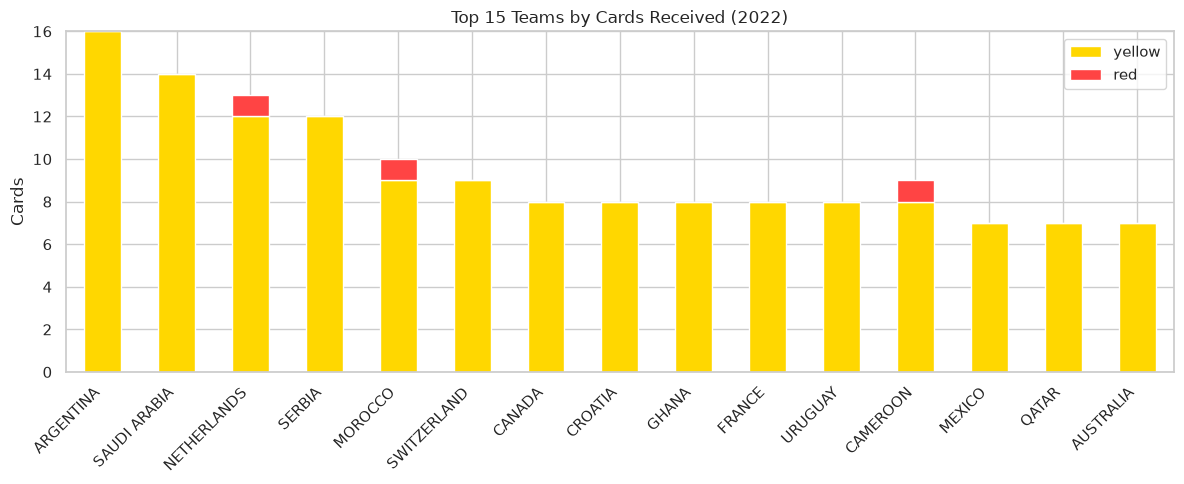

In [43]:
# Cards and discipline
cards_t1 = wc_2022[['team1', 'yellow cards team1', 'red cards team1', 'fouls against team1']].copy()
cards_t1.columns = ['team', 'yellow', 'red', 'fouls']
cards_t2 = wc_2022[['team2', 'yellow cards team2', 'red cards team2', 'fouls against team2']].copy()
cards_t2.columns = ['team', 'yellow', 'red', 'fouls']
all_cards = pd.concat([cards_t1, cards_t2])
team_discipline = all_cards.groupby('team').sum().sort_values('yellow', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 5))
team_discipline[['yellow', 'red']].plot(kind='bar', stacked=True, color=['#FFD700', '#FF4444'], ax=ax)
ax.set_title('Top 15 Teams by Cards Received (2022)')
ax.set_ylabel('Cards')
ax.set_xlabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

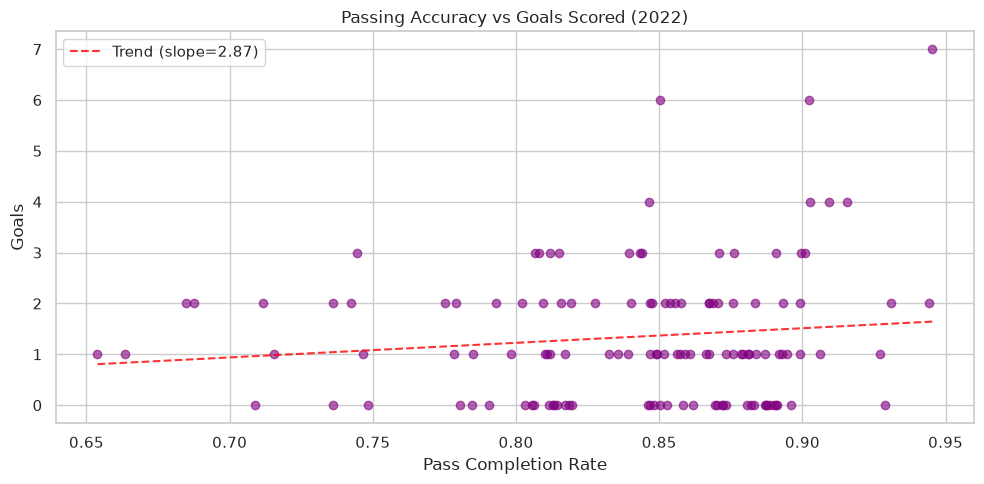

In [44]:
# Passing accuracy
wc_2022['pass_acc_team1'] = wc_2022['passes completed team1'] / wc_2022['passes team1']
wc_2022['pass_acc_team2'] = wc_2022['passes completed team2'] / wc_2022['passes team2']

pass_t1 = wc_2022[['team1', 'pass_acc_team1', 'number of goals team1']].copy()
pass_t1.columns = ['team', 'pass_acc', 'goals']
pass_t2 = wc_2022[['team2', 'pass_acc_team2', 'number of goals team2']].copy()
pass_t2.columns = ['team', 'pass_acc', 'goals']
all_pass = pd.concat([pass_t1, pass_t2])

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(all_pass['pass_acc'], all_pass['goals'], alpha=0.6, color='purple')
z = np.polyfit(all_pass['pass_acc'], all_pass['goals'], 1)
p = np.poly1d(z)
x_line = np.linspace(all_pass['pass_acc'].min(), all_pass['pass_acc'].max(), 100)
ax.plot(x_line, p(x_line), '--', color='red', alpha=0.8, label=f'Trend (slope={z[0]:.2f})')
ax.set_title('Passing Accuracy vs Goals Scored (2022)')
ax.set_xlabel('Pass Completion Rate')
ax.set_ylabel('Goals')
ax.legend()
plt.tight_layout()
plt.show()

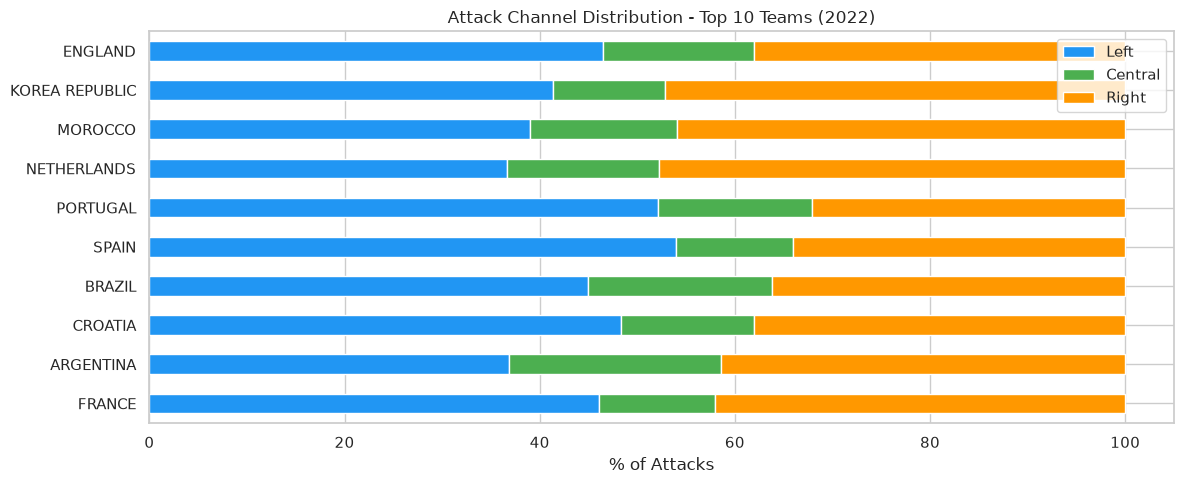

In [45]:
# Channel dominance (left vs central vs right)
channel_t1 = wc_2022[['team1', 'left channel team1', 'central channel team1', 'right channel team1']].copy()
channel_t1.columns = ['team', 'left', 'central', 'right']
channel_t2 = wc_2022[['team2', 'left channel team2', 'central channel team2', 'right channel team2']].copy()
channel_t2.columns = ['team', 'left', 'central', 'right']
all_channels = pd.concat([channel_t1, channel_t2])
team_channels = all_channels.groupby('team').sum()
team_channels_pct = team_channels.div(team_channels.sum(axis=1), axis=0) * 100

top_channel_teams = team_channels.sum(axis=1).nlargest(10).index

fig, ax = plt.subplots(figsize=(12, 5))
team_channels_pct.loc[top_channel_teams].plot(kind='barh', stacked=True,
    color=['#2196F3', '#4CAF50', '#FF9800'], ax=ax)
ax.set_title('Attack Channel Distribution - Top 10 Teams (2022)')
ax.set_xlabel('% of Attacks')
ax.set_ylabel('')
ax.legend(['Left', 'Central', 'Right'])
plt.tight_layout()
plt.show()

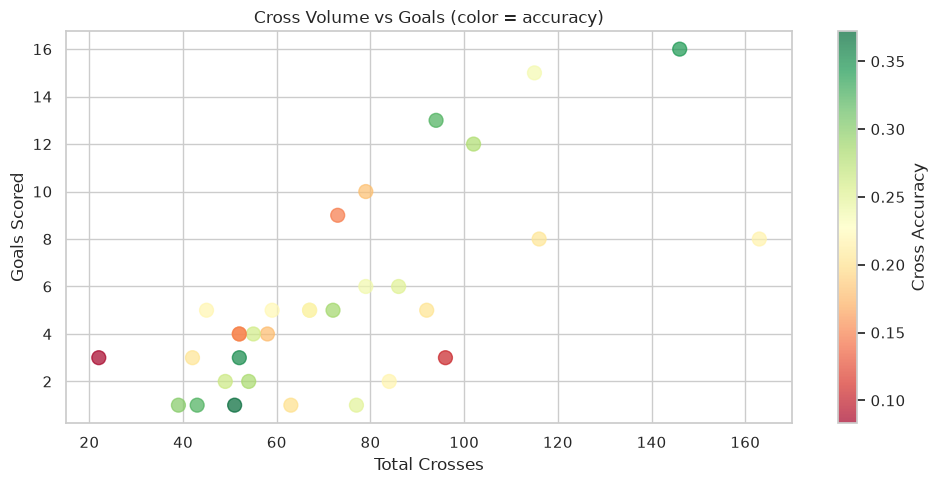

In [46]:
# Crosses and set pieces
wc_2022['cross_acc_t1'] = wc_2022['crosses completed team1'] / wc_2022['crosses team1']
wc_2022['cross_acc_t2'] = wc_2022['crosses completed team2'] / wc_2022['crosses team2']

cross_t1 = wc_2022[['team1', 'crosses team1', 'crosses completed team1', 'cross_acc_t1', 'number of goals team1']].copy()
cross_t1.columns = ['team', 'crosses', 'completed', 'accuracy', 'goals']
cross_t2 = wc_2022[['team2', 'crosses team2', 'crosses completed team2', 'cross_acc_t2', 'number of goals team2']].copy()
cross_t2.columns = ['team', 'crosses', 'completed', 'accuracy', 'goals']
all_cross = pd.concat([cross_t1, cross_t2])
team_crosses = all_cross.groupby('team').agg({'crosses': 'sum', 'completed': 'sum', 'accuracy': 'mean', 'goals': 'sum'})
team_crosses = team_crosses[team_crosses['crosses'] > 20]

fig, ax = plt.subplots(figsize=(10, 5))
scatter = ax.scatter(team_crosses['crosses'], team_crosses['goals'],
                     c=team_crosses['accuracy'], cmap='RdYlGn', s=100, alpha=0.7)
plt.colorbar(scatter, label='Cross Accuracy')
ax.set_title('Cross Volume vs Goals (color = accuracy)')
ax.set_xlabel('Total Crosses')
ax.set_ylabel('Goals Scored')
plt.tight_layout()
plt.show()

## 5. 2026 Preview

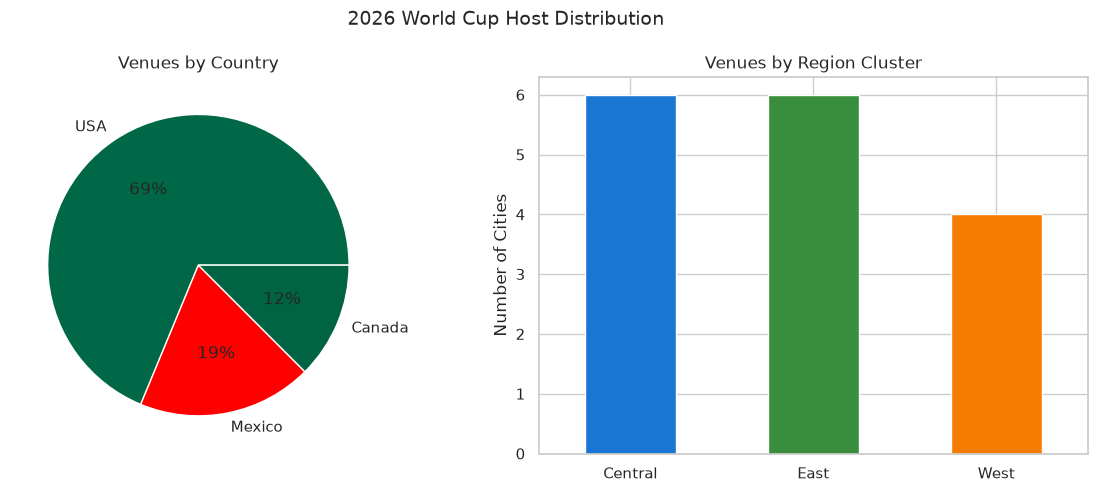

In [47]:
# Host cities geographic distribution
region_counts = wc_2026_host_cities.groupby('region_cluster').agg(
    cities=('city_name', 'count'),
    countries=('country', 'nunique')
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

wc_2026_host_cities['country'].value_counts().plot(kind='pie', autopct='%1.0f%%',
    colors=['#006847', '#FF0000', '#006341'], ax=axes[0])
axes[0].set_title('Venues by Country')
axes[0].set_ylabel('')

region_counts['cities'].plot(kind='bar', color=['#1976D2', '#388E3C', '#F57C00'], ax=axes[1])
axes[1].set_title('Venues by Region Cluster')
axes[1].set_ylabel('Number of Cities')
axes[1].set_xlabel('')
plt.xticks(rotation=0)

fig.suptitle('2026 World Cup Host Distribution', fontsize=14)
plt.tight_layout()
plt.show()

In [48]:
# Group composition - confirmed vs placeholder teams
groups = wc_2026_teams.groupby('group_letter').agg(
    confirmed=('is_placeholder', lambda x: (~x).sum()),
    placeholders=('is_placeholder', 'sum'),
    teams=('team_name', list)
)

print("2026 Group Composition:")
for letter, row in groups.iterrows():
    print(f"\nGroup {letter}: {row['confirmed']} confirmed + {row['placeholders']} TBD")
    for t in row['teams']:
        print(f"  - {t}")

2026 Group Composition:

Group A: 3 confirmed + 1 TBD
  - Mexico
  - South Africa
  - South Korea
  - Winner UEFA Playoff D

Group B: 3 confirmed + 1 TBD
  - Canada
  - Winner UEFA Playoff A
  - Qatar
  - Switzerland

Group C: 4 confirmed + 0 TBD
  - Brazil
  - Morocco
  - Haiti
  - Scotland

Group D: 3 confirmed + 1 TBD
  - USA
  - Paraguay
  - Australia
  - Winner UEFA Playoff C

Group E: 4 confirmed + 0 TBD
  - Germany
  - Curaçao
  - Côte d'Ivoire
  - Ecuador

Group F: 3 confirmed + 1 TBD
  - Netherlands
  - Japan
  - Winner UEFA Playoff B
  - Tunisia

Group G: 4 confirmed + 0 TBD
  - Belgium
  - Egypt
  - Iran
  - New Zealand

Group H: 4 confirmed + 0 TBD
  - Spain
  - Cabo Verde
  - Saudi Arabia
  - Uruguay

Group I: 3 confirmed + 1 TBD
  - France
  - Senegal
  - Winner FIFA Playoff 2
  - Norway

Group J: 4 confirmed + 0 TBD
  - Argentina
  - Algeria
  - Austria
  - Jordan

Group K: 3 confirmed + 1 TBD
  - Portugal
  - Winner FIFA Playoff 1
  - Uzbekistan
  - Colombia

Group L: 4

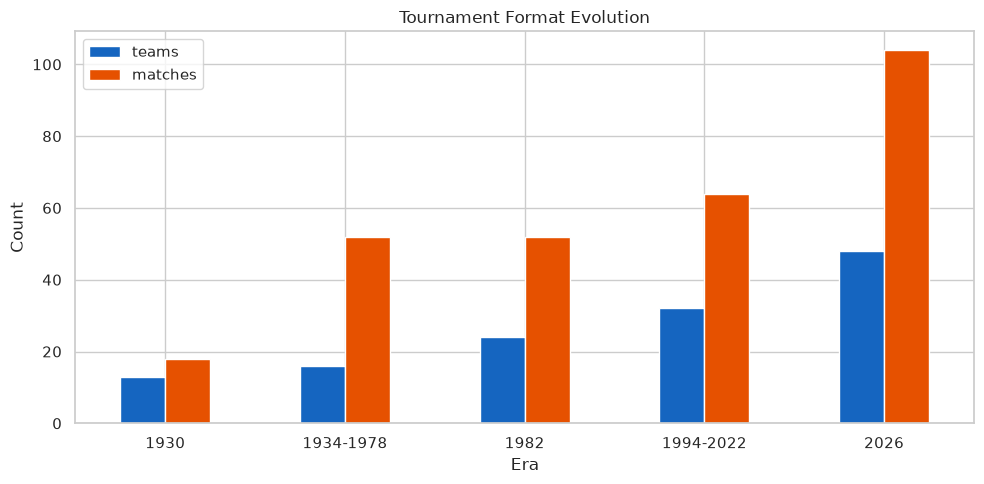

In [49]:
# Tournament format comparison
formats = {
    '1930': {'teams': 13, 'matches': 18, 'stages': 'Groups + Semi + Final'},
    '1934-1978': {'teams': 16, 'matches': 52, 'stages': 'Groups + QF + SF + Final'},
    '1982': {'teams': 24, 'matches': 52, 'stages': 'Groups + 2nd Round + SF + Final'},
    '1994-2022': {'teams': 32, 'matches': 64, 'stages': 'Groups + R16 + QF + SF + Final'},
    '2026': {'teams': 48, 'matches': 104, 'stages': 'Groups + R32 + R16 + QF + SF + Final'},
}

fmt_df = pd.DataFrame(formats).T
fig, ax = plt.subplots(figsize=(10, 5))
fmt_df[['teams', 'matches']].plot(kind='bar', ax=ax, color=['#1565C0', '#E65100'])
ax.set_title('Tournament Format Evolution')
ax.set_ylabel('Count')
ax.set_xlabel('Era')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 6. Cross-Era Comparison

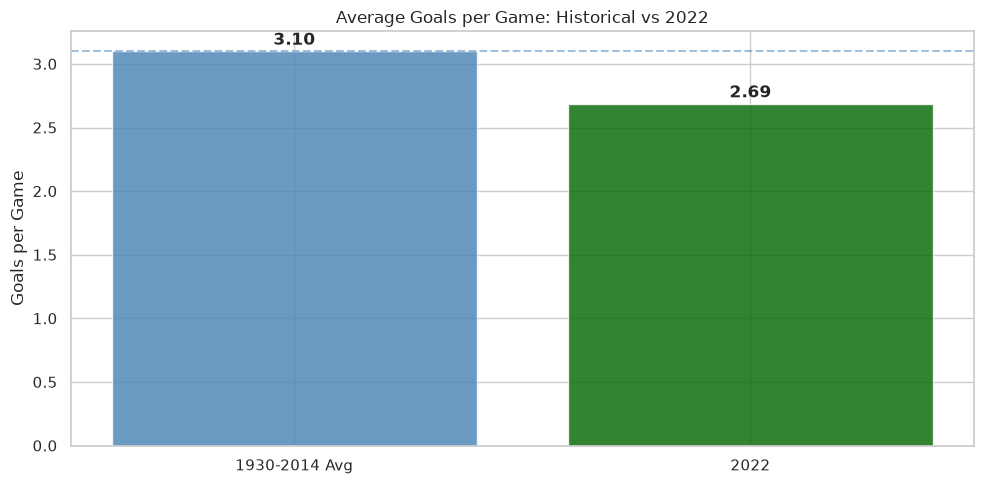

In [50]:
# Compare average goals per game across eras (including 2018 preview data)
avg_gpg_hist = yearly['goals_per_game'].mean()
avg_gpg_2022 = wc_2022['total_goals'].mean()

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(['1930-2014 Avg', '2022'], [avg_gpg_hist, avg_gpg_2022],
              color=['steelblue', 'darkgreen'], alpha=0.8)
ax.axhline(y=avg_gpg_hist, color='steelblue', linestyle='--', alpha=0.5)
ax.set_title('Average Goals per Game: Historical vs 2022')
ax.set_ylabel('Goals per Game')
for bar, val in zip(bars, [avg_gpg_hist, avg_gpg_2022]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val:.2f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

# 2018 team experience summary
print("\n2018 Tournament - Team Experience Summary:")
print(f"  Teams with previous titles: {(wc_2018['Prev Titles'] > 0).sum()} of {len(wc_2018)}")
print(f"  Teams making debut: {(wc_2018['Prev Appearances'] == 0).sum()}")
print(f"  Average FIFA rank: {wc_2018['FIFA Rank'].mean():.1f}")
print(f"  Median FIFA rank: {wc_2018['FIFA Rank'].median():.1f}")

In [51]:
# Statistical summary by era
wc_1930_2014['total_goals_match'] = wc_1930_2014['Home Team Goals'] + wc_1930_2014['Away Team Goals']

print("="*70)
print("Statistical Comparison Across Eras")
print("="*70)
print(f"\n{'Metric':<30} {'1930-2014':>12} {'2018 (preview)':>16} {'2022':>12}")
print("-"*70)
print(f"{'Total matches':<30} {len(wc_1930_2014):>12} {'48 (teams)':>16} {len(wc_2022):>12}")
print(f"{'Avg goals/match':<30} {wc_1930_2014['total_goals_match'].mean():>12.2f} {'N/A':>16} {wc_2022['total_goals'].mean():>12.2f}")
print(f"{'Max goals in match':<30} {wc_1930_2014['total_goals_match'].max():>12.0f} {'N/A':>16} {wc_2022['total_goals'].max():>12.0f}")
print(f"{'Avg attendance':<30} {wc_1930_2014['Attendance'].mean():>12,.0f} {'N/A':>16} {'N/A':>12}")
print(f"{'Home win %':<30} {home_wins_count/len(wc_1930_2014)*100:>11.1f}% {'N/A':>16} {(wc_2022['goal_diff']>0).sum()/len(wc_2022)*100:>11.1f}%")
print(f"{'Draw %':<30} {draws/len(wc_1930_2014)*100:>11.1f}% {'N/A':>16} {(wc_2022['goal_diff']==0).sum()/len(wc_2022)*100:>11.1f}%")
print(f"{'Teams with past titles (2018)':<30} {'N/A':>12} {(wc_2018['Prev Titles']>0).sum():>16} {'N/A':>12}")
print(f"{'Debut teams (2018)':<30} {'N/A':>12} {(wc_2018['Prev Appearances']==0).sum():>16} {'N/A':>12}")

Statistical Comparison

Metric                            1930-2014         2022
------------------------------------------------------
Total matches                           852           64
Avg goals/match                        2.83         2.69
Max goals in match                       12            8
Avg attendance                       45,165          N/A
Home win %                            57.3%        45.3%
Draw %                                22.3%        23.4%


## 7. Visualization Summary

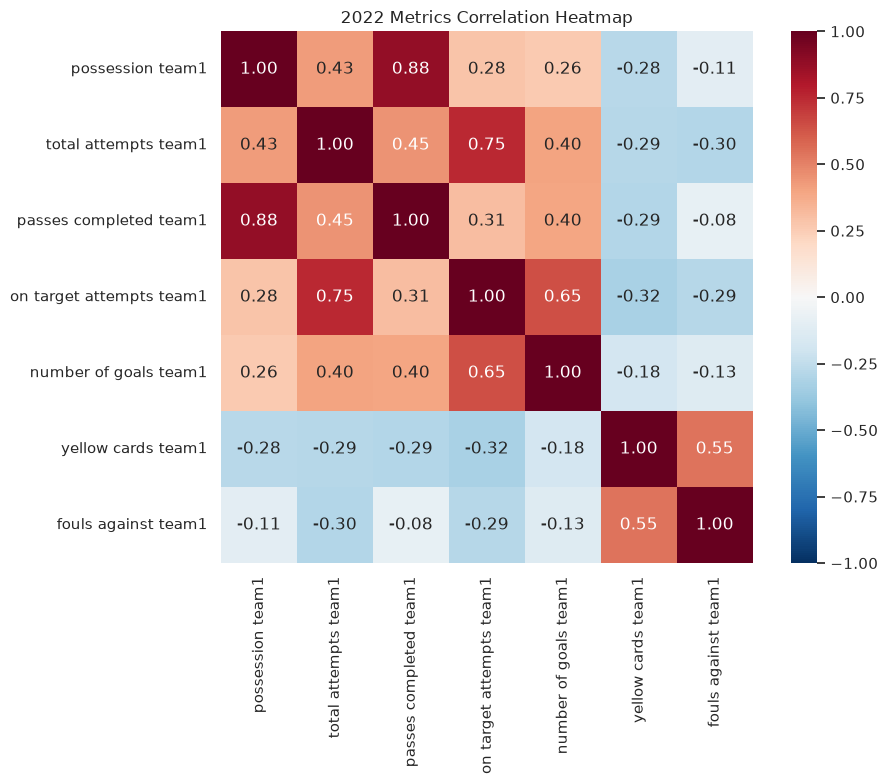

In [52]:
# Correlation heatmap of key 2022 metrics
key_cols = ['possession team1', 'total attempts team1', 'passes completed team1',
            'on target attempts team1', 'number of goals team1',
            'yellow cards team1', 'fouls against team1']
corr = wc_2022[key_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, ax=ax, vmin=-1, vmax=1)
ax.set_title('2022 Metrics Correlation Heatmap')
plt.tight_layout()
plt.show()

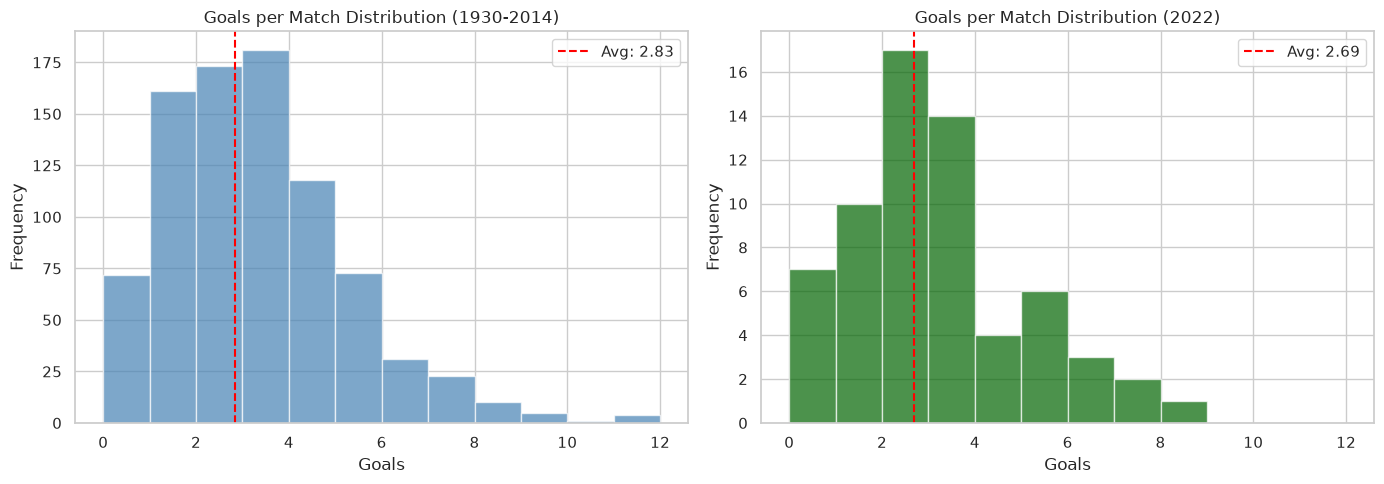

In [53]:
# Goals distribution comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(wc_1930_2014['total_goals_match'], bins=range(0, 13), color='steelblue', alpha=0.7, edgecolor='white')
axes[0].set_title('Goals per Match Distribution (1930-2014)')
axes[0].set_xlabel('Goals')
axes[0].set_ylabel('Frequency')
axes[0].axvline(wc_1930_2014['total_goals_match'].mean(), color='red', linestyle='--', label=f"Avg: {wc_1930_2014['total_goals_match'].mean():.2f}")
axes[0].legend()

axes[1].hist(wc_2022['total_goals'], bins=range(0, 13), color='darkgreen', alpha=0.7, edgecolor='white')
axes[1].set_title('Goals per Match Distribution (2022)')
axes[1].set_xlabel('Goals')
axes[1].set_ylabel('Frequency')
axes[1].axvline(wc_2022['total_goals'].mean(), color='red', linestyle='--', label=f"Avg: {wc_2022['total_goals'].mean():.2f}")
axes[1].legend()

plt.tight_layout()
plt.show()

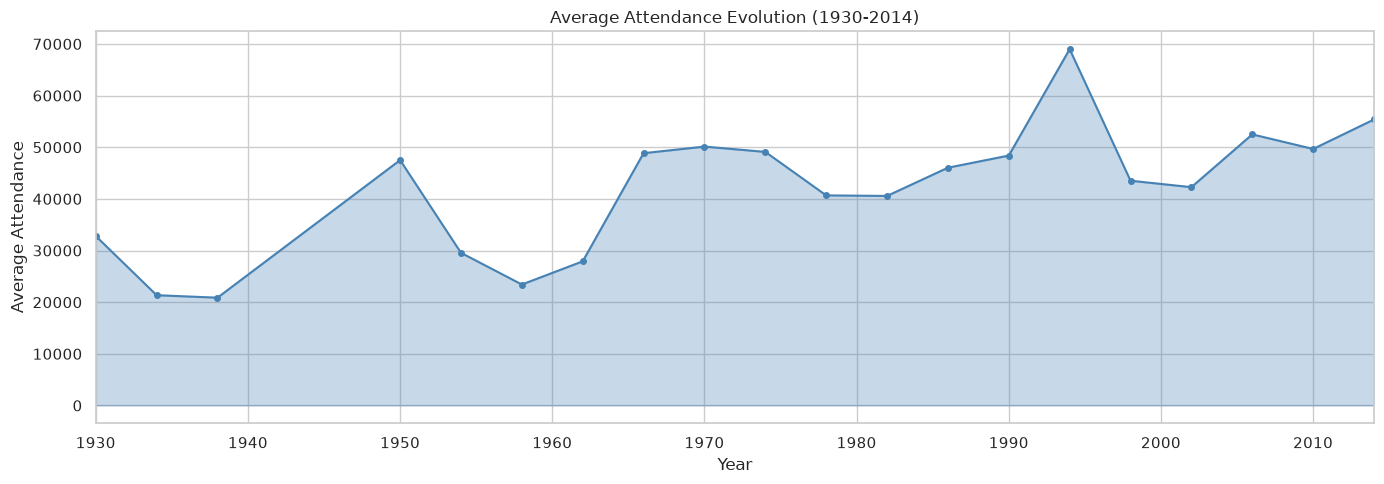

In [54]:
# Attendance evolution
fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(yearly['Year'], yearly['avg_attendance'], alpha=0.3, color='steelblue')
ax.plot(yearly['Year'], yearly['avg_attendance'], color='steelblue', marker='o', markersize=4)
ax.set_title('Average Attendance Evolution (1930-2014)')
ax.set_xlabel('Year')
ax.set_ylabel('Average Attendance')
ax.set_xlim(1930, 2014)
plt.tight_layout()
plt.show()

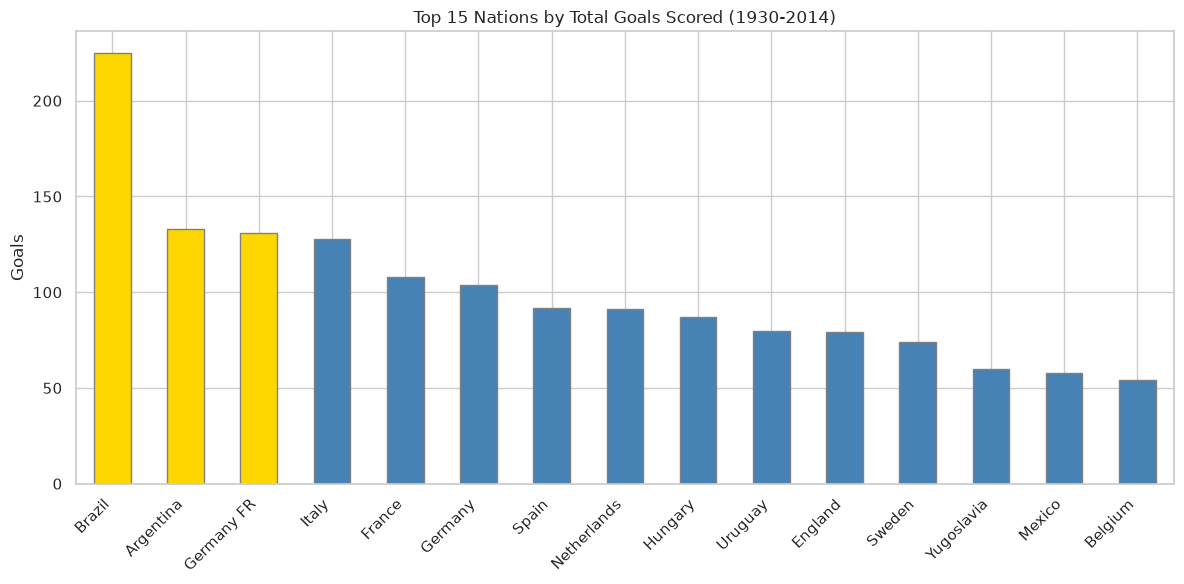

In [55]:
# Top scoring nations all-time
home_goals_by_team = wc_1930_2014.groupby('Home Team Name')['Home Team Goals'].sum()
away_goals_by_team = wc_1930_2014.groupby('Away Team Name')['Away Team Goals'].sum()
total_goals_all = (home_goals_by_team.add(away_goals_by_team, fill_value=0)).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#FFD700' if i < 3 else '#4682B4' for i in range(15)]
total_goals_all.plot(kind='bar', color=colors, edgecolor='gray', ax=ax)
ax.set_title('Top 15 Nations by Total Goals Scored (1930-2014)')
ax.set_ylabel('Goals')
ax.set_xlabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()